# Time Cell Minimal Loop (Train → Evaluate → Plot)
This notebook is **self-contained** (no `torchvision` dependency) and is designed to run a minimal closed-loop pipeline:
1) Load variable-length trajectory folders (pkl + images)
2) Train a Visual-Temporal LSTM model
3) Evaluate (MSE/R²) and plot predicted vs GT trajectory

**You only need to set `DATA_ROOT_DIR` to your dataset path.**

In [1]:
# === 0) Imports & Reproducibility ===
import os, re, pickle, math, random
from glob import glob
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
# === 1) Config (EDIT THIS) ===
DATA_ROOT_DIR = "/media/zhen/Data/Datasets/nomad_data/go_stanford"  # <-- CHANGE ME
SAVE_DIR = "./eval_results_minimal"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 8
EPOCHS = 5           # start small for sanity; increase later (e.g., 50-200)
LR = 1e-4
HIDDEN_DIM = 128
VISUAL_DIM = 256

USE_YAW = True
MIN_LEN = 3
IMG_SIZE = (64, 64)

CKPT_PATH = os.path.join(SAVE_DIR, "best_timecell_model.pth")


In [3]:
# === 2) Dataset (variable-length trajectory folders: traj_data.pkl + images) ===

def sort_key(path: str) -> int:
    nums = re.findall(r"\d+", os.path.basename(path))
    return int(nums[-1]) if nums else 0

def pil_to_tensor(img: Image.Image) -> torch.Tensor:
    """Convert PIL RGB image to torch float tensor [3,H,W] in [0,1] without torchvision."""
    arr = np.asarray(img, dtype=np.float32) / 255.0  # [H,W,3]
    if arr.ndim == 2:
        arr = np.repeat(arr[..., None], 3, axis=2)
    arr = np.transpose(arr, (2, 0, 1))              # [3,H,W]
    return torch.from_numpy(arr)

class VariableLengthTrajectoryDataset(Dataset):
    """
    Each trajectory is a folder containing:
      - traj_data.pkl with keys: 'position' (Tx2 or Tx3), 'yaw' (T,)
      - images: *.jpg or *.png directly under the folder
    Target: last position (pos[-1])
    Features per step: [pos, yaw] (if USE_YAW) else [pos]
    """
    def __init__(self, root_dir: str, use_yaw: bool=True, min_len: int=3, img_size=(64,64)):
        if not os.path.exists(root_dir):
            raise FileNotFoundError(f"Dataset root directory not found: {root_dir}")
        self.root_dir = root_dir
        self.use_yaw = use_yaw
        self.min_len = min_len
        self.img_size = img_size

        self.trajectories = sorted([
            os.path.join(root_dir, d)
            for d in os.listdir(root_dir)
            if os.path.isdir(os.path.join(root_dir, d))
        ])
        if len(self.trajectories) == 0:
            raise ValueError(f"No trajectory folders found under: {root_dir}")
        print(f"✅ Found {len(self.trajectories)} trajectories in {root_dir}")

        # infer dims from first valid sample
        self.target_dim = None
        self.input_feature_dim = None
        for tp in self.trajectories[:10]:
            pkl_path = os.path.join(tp, "traj_data.pkl")
            if not os.path.exists(pkl_path):
                continue
            with open(pkl_path, "rb") as f:
                data = pickle.load(f)
            pos = np.asarray(data.get("position", []), dtype=np.float32)
            yaw = np.asarray(data.get("yaw", []), dtype=np.float32)
            if pos.ndim != 2 or len(pos) < self.min_len:
                continue
            self.target_dim = pos.shape[1]
            self.input_feature_dim = self.target_dim + (1 if (self.use_yaw and yaw.size > 0) else 0)
            break
        if self.target_dim is None:
            raise RuntimeError("Failed to infer target_dim/input_feature_dim. Check your pkl files.")
        print(f"Detected target_dim (position) = {self.target_dim}")
        print(f"Detected input_feature_dim (pos + yaw={self.use_yaw}) = {self.input_feature_dim}")

    def __len__(self):
        return len(self.trajectories)

    def _load_pkl(self, traj_path):
        pkl_path = os.path.join(traj_path, "traj_data.pkl")
        if not os.path.exists(pkl_path):
            return None
        with open(pkl_path, "rb") as f:
            data = pickle.load(f)
        pos = np.asarray(data["position"], dtype=np.float32)
        yaw = np.asarray(data.get("yaw", []), dtype=np.float32)
        return pos, yaw

    def _load_images(self, traj_path):
        img_files = sorted(glob(os.path.join(traj_path, "*.jpg")), key=sort_key)
        if not img_files:
            img_files = sorted(glob(os.path.join(traj_path, "*.png")), key=sort_key)
        imgs = []
        for fp in img_files:
            img = Image.open(fp).convert("RGB").resize(self.img_size)
            imgs.append(pil_to_tensor(img))
        if len(imgs) == 0:
            return None
        return torch.stack(imgs, dim=0)  # [T,3,H,W]

    def __getitem__(self, idx):
        traj_path = self.trajectories[idx]
        loaded = self._load_pkl(traj_path)
        if loaded is None:
            return None
        pos, yaw = loaded
        imgs = self._load_images(traj_path)
        if imgs is None:
            return None

        T = min(len(pos), imgs.shape[0])
        if T < self.min_len:
            return None

        pos = pos[:T]
        imgs = imgs[:T]
        if self.use_yaw and yaw.size > 0:
            yaw = yaw[:T].reshape(T, 1).astype(np.float32)
            feats = np.concatenate([pos, yaw], axis=1)  # [T, Dpos+1]
        else:
            feats = pos  # [T, Dpos]

        feats = torch.from_numpy(feats).float()
        target = torch.from_numpy(pos[-1]).float()     # [Dpos]
        return feats, imgs, target

def collate_variable_length(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None, None, None, None
    feats, imgs, targets = zip(*batch)
    lengths = [f.shape[0] for f in feats]
    max_len = max(lengths)

    B = len(batch)
    feat_dim = feats[0].shape[1]
    C, H, W = imgs[0].shape[1], imgs[0].shape[2], imgs[0].shape[3]

    feats_pad = torch.zeros(B, max_len, feat_dim, dtype=torch.float32)
    imgs_pad  = torch.zeros(B, max_len, C, H, W, dtype=torch.float32)
    mask      = torch.zeros(B, max_len, dtype=torch.bool)

    for i, (f, im) in enumerate(zip(feats, imgs)):
        L = f.shape[0]
        feats_pad[i, :L] = f
        imgs_pad[i, :L] = im
        mask[i, :L] = True

    targets = torch.stack(targets, dim=0)
    return feats_pad, imgs_pad, targets, mask

# build loader
dataset = VariableLengthTrajectoryDataset(DATA_ROOT_DIR, use_yaw=USE_YAW, min_len=MIN_LEN, img_size=IMG_SIZE)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_variable_length)

# sanity: peek one batch
batch = next(iter(loader))
feats, imgs, targets, mask = batch
print("feats:", feats.shape, "imgs:", imgs.shape, "targets:", targets.shape, "mask:", mask.shape, "mask_valid:", mask.sum().item())


✅ Found 3696 trajectories in /media/zhen/Data/Datasets/nomad_data/go_stanford
Detected target_dim (position) = 2
Detected input_feature_dim (pos + yaw=True) = 3


/tmp/ipykernel_1987762/3220069749.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)
/tmp/ipykernel_1987762/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


feats: torch.Size([5, 47, 3]) imgs: torch.Size([5, 47, 3, 64, 64]) targets: torch.Size([5, 2]) mask: torch.Size([5, 47]) mask_valid: 149


In [4]:
# === 3) Model (VisualTemporalNet without torchvision) ===

class VisualTemporalNet(nn.Module):
    def __init__(self, feature_dim: int, hidden_dim: int, visual_dim: int, output_dim: int):
        super().__init__()
        self.feature_dim = feature_dim
        self.hidden_dim = hidden_dim
        self.visual_dim = visual_dim
        self.output_dim = output_dim

        # CNN encoder (expects 64x64)
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, visual_dim), nn.ReLU()
        )

        # LSTM consumes concatenated [feats, visual]
        self.lstm = nn.LSTM(input_size=feature_dim + visual_dim, hidden_size=hidden_dim,
                            num_layers=1, batch_first=True)

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, feats, imgs, mask):
        # feats: [B,T,F], imgs: [B,T,3,H,W], mask: [B,T]
        B, T, _, H, W = imgs.shape
        imgs_flat = imgs.view(B*T, 3, H, W)
        v = self.cnn(imgs_flat).view(B, T, self.visual_dim)  # [B,T,V]

        x = torch.cat([feats, v], dim=-1)  # [B,T,F+V]

        lengths = mask.sum(dim=1).long().cpu()  # [B]
        # pack for variable-length
        packed = nn.utils.rnn.pack_padded_sequence(x, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=T)  # [B,T,H]

        # take last valid step per sequence
        idx = (lengths - 1).clamp(min=0).to(out.device)  # [B]
        last = out[torch.arange(B, device=out.device), idx]  # [B,H]
        pred = self.fc(last)  # [B,output_dim]
        return pred, out  # return full LSTM outputs for time-cell analyses later

model = VisualTemporalNet(
    feature_dim=dataset.input_feature_dim,
    hidden_dim=HIDDEN_DIM,
    visual_dim=VISUAL_DIM,
    output_dim=dataset.target_dim
).to(device)

# forward sanity
feats, imgs, targets, mask = next(iter(loader))
feats, imgs, targets, mask = feats.to(device), imgs.to(device), targets.to(device), mask.to(device)
pred, lstm_out = model(feats, imgs, mask)
print("pred:", pred.shape, "targets:", targets.shape, "lstm_out:", lstm_out.shape)
assert pred.shape == targets.shape, "❌ pred.shape must match targets.shape"


/tmp/ipykernel_1987762/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


pred: torch.Size([6, 2]) targets: torch.Size([6, 2]) lstm_out: torch.Size([6, 201, 128])


In [ ]:
# === 4) Train (minimal) ===

def train_minimal(model, loader, device, epochs=10, lr=1e-4, ckpt_path=CKPT_PATH):
    model.to(device)
    loss_fn = nn.SmoothL1Loss()
    optim = torch.optim.Adam(model.parameters(), lr=lr)
    best = float("inf")

    for ep in range(1, epochs+1):
        model.train()
        total = 0.0
        n = 0
        for batch in loader:
            feats, imgs, targets, mask = batch
            if feats is None:
                continue
            feats, imgs, targets, mask = feats.to(device), imgs.to(device), targets.to(device), mask.to(device)

            optim.zero_grad(set_to_none=True)
            pred, _ = model(feats, imgs, mask)

            loss = loss_fn(pred, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optim.step()

            total += loss.item()
            n += 1

        avg = total / max(n, 1)
        print(f"Epoch {ep}/{epochs} | loss={avg:.6f}")

        if avg < best:
            best = avg
            torch.save(model.state_dict(), ckpt_path)
            print(f"✅ New best saved: {ckpt_path} (loss={best:.6f})")

    return ckpt_path

ckpt = train_minimal(model, loader, device, epochs=EPOCHS, lr=LR, ckpt_path=CKPT_PATH)


/tmp/ipykernel_1987762/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


Epoch 1/5 | loss=12.204112
✅ New best saved: ./eval_results_minimal/best_timecell_model.pth (loss=12.204112)
Epoch 2/5 | loss=10.699825
✅ New best saved: ./eval_results_minimal/best_timecell_model.pth (loss=10.699825)
Epoch 3/5 | loss=9.323403
✅ New best saved: ./eval_results_minimal/best_timecell_model.pth (loss=9.323403)
Epoch 4/5 | loss=8.163670
✅ New best saved: ./eval_results_minimal/best_timecell_model.pth (loss=8.163670)
Epoch 5/5 | loss=7.150253
✅ New best saved: ./eval_results_minimal/best_timecell_model.pth (loss=7.150253)


/tmp/ipykernel_1987762/3220069749.py:71: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  yaw = np.asarray(data.get("yaw", []), dtype=np.float32)


Eval | MSE=183.888031 | R2=0.5389


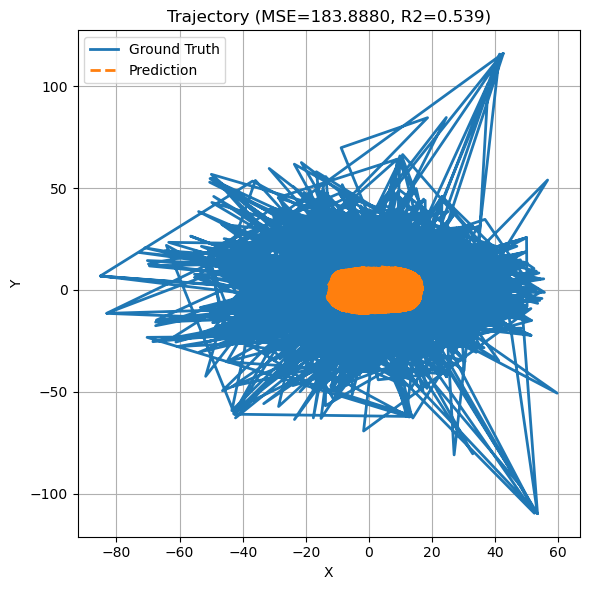

Saved plot: ./eval_results_minimal/timecell_minimal_traj.png


In [6]:
# === 5) Evaluate + Plot (minimal loop output) ===

@torch.no_grad()
def evaluate_and_plot(model, loader, device, ckpt_path, save_dir=SAVE_DIR, prefix="timecell"):
    os.makedirs(save_dir, exist_ok=True)
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    model.to(device)
    model.eval()

    preds_all, targets_all = [], []
    for batch in loader:
        feats, imgs, targets, mask = batch
        if feats is None:
            continue
        feats, imgs, targets, mask = feats.to(device), imgs.to(device), targets.to(device), mask.to(device)
        pred, _ = model(feats, imgs, mask)
        preds_all.append(pred.detach().cpu().numpy())
        targets_all.append(targets.detach().cpu().numpy())

    preds_all = np.concatenate(preds_all, axis=0)
    targets_all = np.concatenate(targets_all, axis=0)

    mse = mean_squared_error(targets_all, preds_all)
    r2 = r2_score(targets_all, preds_all)
    print(f"Eval | MSE={mse:.6f} | R2={r2:.4f}")

    np.save(os.path.join(save_dir, f"{prefix}_preds.npy"), preds_all)
    np.save(os.path.join(save_dir, f"{prefix}_targets.npy"), targets_all)

    # Trajectory plot (assumes first 2 dims are x,y)
    if preds_all.shape[1] >= 2 and targets_all.shape[1] >= 2:
        plt.figure(figsize=(6,6))
        plt.plot(targets_all[:,0], targets_all[:,1], '-', linewidth=2, label="Ground Truth")
        plt.plot(preds_all[:,0], preds_all[:,1], '--', linewidth=2, label="Prediction")
        plt.title(f"Trajectory (MSE={mse:.4f}, R2={r2:.3f})")
        plt.xlabel("X"); plt.ylabel("Y")
        plt.grid(True); plt.legend()
        out_path = os.path.join(save_dir, f"{prefix}_traj.png")
        plt.tight_layout()
        plt.savefig(out_path, dpi=200)
        plt.show()
        print("Saved plot:", out_path)
    else:
        print("Skip trajectory plot: target_dim < 2")

    # metrics csv
    import pandas as pd
    pd.DataFrame([{"MSE": mse, "R2": r2, "n": len(preds_all)}]).to_csv(
        os.path.join(save_dir, f"{prefix}_metrics.csv"), index=False
    )
    return preds_all, targets_all, {"MSE": mse, "R2": r2}

preds, targets, metrics = evaluate_and_plot(model, loader, device, ckpt, save_dir=SAVE_DIR, prefix="timecell_minimal")
